# Demand forecasting with LSTM

This notebook style script follows the same overall build up as the forecasting 'Assignment 2' in energy analytics, but the target is now hourly electricity demand. 

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
#Set global font sizes
plt.rcParams.update({
    "font.size": 14,            # Base font size
    "axes.titlesize": 16,       # Title size
    "axes.labelsize": 14,       # Axis label size
    "xtick.labelsize": 12,      # X-axis tick labels
    "ytick.labelsize": 12,      # Y-axis tick labels
    "legend.fontsize": 12,      # Legend text
})

### Data processing

In [3]:
def create_sequences(X, y, look_back, look_ahead):
    X_out, y_out = [], []

    for i in range(look_back, len(X) - look_ahead + 1):
        x_seq = X[i - look_back:i]
        y_seq = y[i:i + look_ahead, 0]

        X_out.append(x_seq)
        y_out.append(y_seq)

    return np.array(X_out), np.array(y_out)

### Data processing

In [4]:
FILE_NAME = "Consumption_two_years.csv"
REGION = "Region Hovedstaden"
CATEGORY2 = "Privat"

file_data = os.path.join(os.getcwd(), FILE_NAME)
df_raw = pd.read_csv(file_data, sep=";")

df_raw["TimeUTC"] = pd.to_datetime(df_raw["TimeUTC"])
df_raw["TimeDK"] = pd.to_datetime(df_raw["TimeDK"])

df_raw["ConsumptionkWh"] = (
    df_raw["ConsumptionkWh"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_raw = df_raw[
    (df_raw["RegionName"] == REGION) &
    (df_raw["ConsumerCategory2"] == CATEGORY2)
].copy()

df_raw = df_raw.sort_values("TimeUTC").reset_index(drop=True)

df_hourly = (
    df_raw.groupby("TimeUTC", as_index=False)["ConsumptionkWh"]
    .sum()
    .sort_values("TimeUTC")
    .reset_index(drop=True)
)

# exogenous variables 
df_hourly["hour"] = df_hourly["TimeUTC"].dt.hour
df_hourly["weekday"] = df_hourly["TimeUTC"].dt.weekday
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["is_weekend"] = (df_hourly["weekday"] >= 5).astype(int)

# Looks at the last 24 hours and the same hour last week as features
df_hourly["lag_1"] = df_hourly["ConsumptionkWh"].shift(1)
df_hourly["lag_24"] = df_hourly["ConsumptionkWh"].shift(24)
df_hourly["lag_168"] = df_hourly["ConsumptionkWh"].shift(168)

df_hourly = df_hourly.dropna().reset_index(drop=True)

print(df_hourly[["ConsumptionkWh", "lag_24", "lag_168"]].head(200))


df_hourly = df_hourly.set_index("TimeUTC").asfreq("h")

print(df_hourly.index.min())
print(df_hourly.index.max())
print(df_hourly.isna().sum())


print(df_hourly.shape)
df_hourly.head()


     ConsumptionkWh      lag_24     lag_168
0        404162.262  436928.583  305809.198
1        406760.450  431417.697  297950.077
2        394857.401  423902.403  286149.481
3        382076.182  411391.982  268110.603
4        358977.139  390252.338  246388.437
..              ...         ...         ...
195      380435.072  314586.185  364928.165
196      356228.944  287150.182  330213.163
197      346075.559  278351.195  318580.553
198      387910.516  319798.489  355226.012
199      429796.579  363581.811  391713.155

[200 rows x 3 columns]
2024-01-07 23:00:00
2026-03-30 21:00:00
ConsumptionkWh    0
hour              0
weekday           0
hour_sin          0
hour_cos          0
is_weekend        0
lag_1             0
lag_24            0
lag_168           0
dtype: int64
(19511, 9)


,ConsumptionkWh,hour,weekday,hour_sin,hour_cos,is_weekend,lag_1,lag_24,lag_168
TimeUTC,,,,,,,,,
2024-01-07 23:00:00,404162.262,23,6,-0.258819,0.965926,1,403293.733,436928.583,305809.198
2024-01-08 00:00:00,406760.450,0,0,0.000000,1.000000,0,404162.262,431417.697,297950.077
2024-01-08 01:00:00,394857.401,1,0,0.258819,0.965926,0,406760.450,423902.403,286149.481
2024-01-08 02:00:00,382076.182,2,0,0.500000,0.866025,0,394857.401,411391.982,268110.603
2024-01-08 03:00:00,358977.139,3,0,0.707107,0.707107,0,382076.182,390252.338,246388.437


### Plot of demand series 

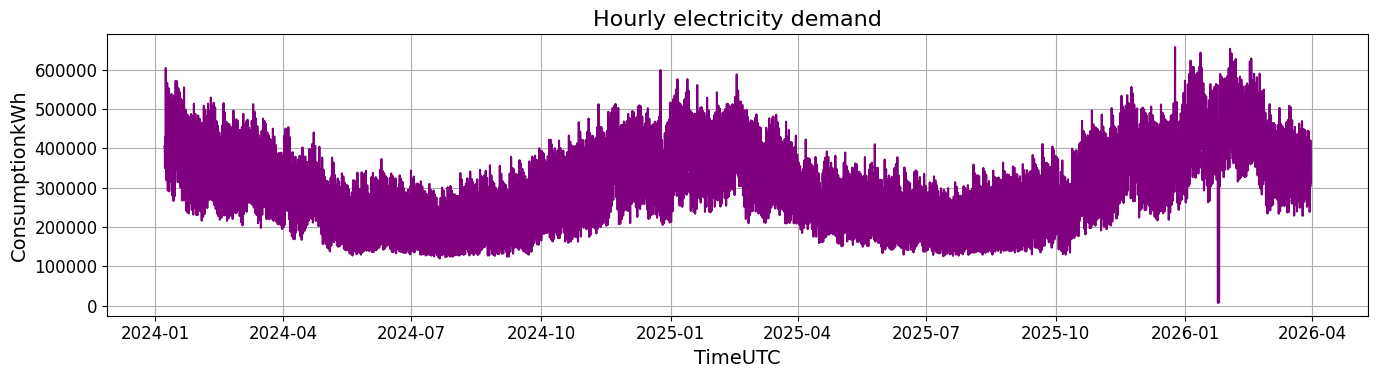

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df_hourly.index, df_hourly["ConsumptionkWh"], color="purple")
plt.xlabel("TimeUTC")
plt.ylabel("ConsumptionkWh")
plt.title("Hourly electricity demand")
plt.grid()
plt.tight_layout()
plt.show()

### Tran and test split

In [6]:
look_back = 72
look_ahead = 24 

test_start = pd.to_datetime("2025-04-01 00:00:00")
test_end = pd.to_datetime("2025-04-30 23:00:00")
train_end = test_start - pd.Timedelta(hours=1) #training on all available data up to the test period

df_lstm = df_hourly.loc[:test_end].copy()

trainval_df = df_lstm.loc[:train_end].copy()
test_df = df_lstm.loc[test_start:test_end].copy()

print("Train and validation period:")
print(trainval_df.index.min(), "to", trainval_df.index.max())

print("\nTest period:")
print(test_df.index.min(), "to", test_df.index.max())

Train and validation period:
2024-01-07 23:00:00 to 2025-03-31 23:00:00

Test period:
2025-04-01 00:00:00 to 2025-04-30 23:00:00


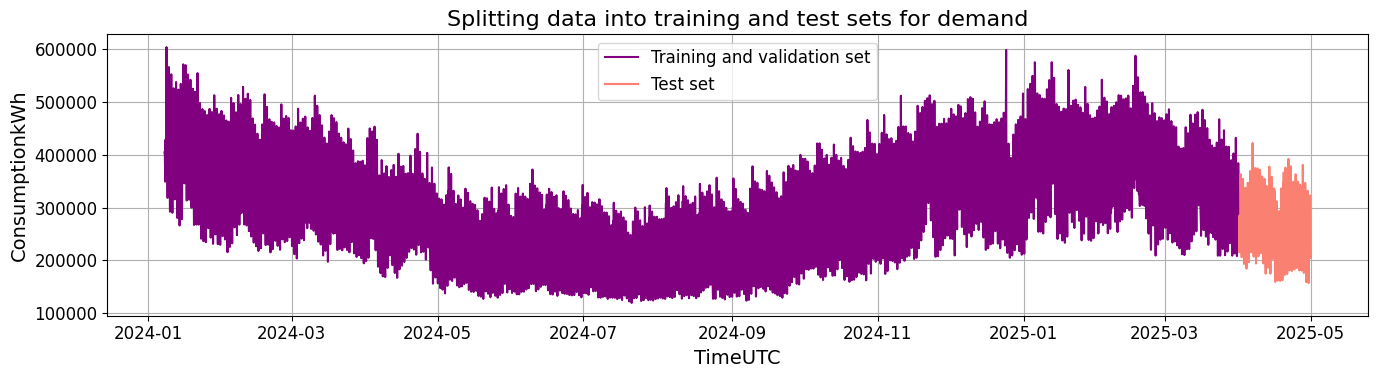

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(trainval_df.index, trainval_df["ConsumptionkWh"], color="purple", label="Training and validation set")
plt.plot(test_df.index, test_df["ConsumptionkWh"], color="salmon", label="Test set")
plt.xlabel("TimeUTC")
plt.ylabel("ConsumptionkWh")
plt.title("Splitting data into training and test sets for demand")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### Preparing input features and scale data 

In [8]:
feature_cols = [
    "ConsumptionkWh",
    "lag_1",
    "lag_24",
    "lag_168",
    "hour_sin",
    "hour_cos",
    "is_weekend"
]
target_col = ["ConsumptionkWh"]

X_full = df_lstm[feature_cols].values
y_full = df_lstm[target_col].values

test_start_idx = df_lstm.index.get_loc(test_start)
test_end_idx = df_lstm.index.get_loc(test_end) + 1

# Train/validation split
X_trainval = X_full[:test_start_idx]
y_trainval = y_full[:test_start_idx]

# Test set (with look_back history included)
X_test = X_full[test_start_idx - look_back:test_end_idx]
y_test = y_full[test_start_idx - look_back:test_end_idx]

# Save index for correct timestamp alignment
test_input_index = df_lstm.index[test_start_idx - look_back:test_end_idx]

# Scaling
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_trainval_scaled = X_scaler.fit_transform(X_trainval)
y_trainval_scaled = y_scaler.fit_transform(y_trainval)

X_test_scaled = X_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

### Splitting training and validation

In [9]:
val_size = int(0.2 * len(X_trainval_scaled))

X_train_scaled = X_trainval_scaled[:-val_size]
y_train_scaled = y_trainval_scaled[:-val_size]

X_val_scaled = X_trainval_scaled[-val_size:]
y_val_scaled = y_trainval_scaled[-val_size:]

print("Training rows:", len(X_train_scaled))
print("Validation rows:", len(X_val_scaled))
print("Test rows:", len(X_test_scaled))


Training rows: 8622
Validation rows: 2155
Test rows: 792


### Sequences for LSTM model 

In [10]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, look_back, look_ahead)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, look_back, look_ahead)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, look_back, look_ahead)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("y_val_seq shape:", y_val_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)



X_train_seq shape: (8527, 72, 7)
y_train_seq shape: (8527, 24)
X_val_seq shape: (2060, 72, 7)
y_val_seq shape: (2060, 24)
X_test_seq shape: (697, 72, 7)
y_test_seq shape: (697, 24)


### Build and train the LSTM 

In [11]:
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64),
    Dense(look_ahead)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start = time.time()

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("Training time: {:.2f} seconds".format(time.time() - start))

Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - loss: 0.0141 - mae: 0.0818 - val_loss: 0.0087 - val_mae: 0.0745
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.0049 - mae: 0.0547 - val_loss: 0.0072 - val_mae: 0.0680
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.0040 - mae: 0.0492 - val_loss: 0.0061 - val_mae: 0.0628
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 0.0033 - mae: 0.0443 - val_loss: 0.0051 - val_mae: 0.0562
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - loss: 0.0028 - mae: 0.0407 - val_loss: 0.0047 - val_mae: 0.0533
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.0025 - mae: 0.0385 - val_loss: 0.0041 - val_mae: 0.0501
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - loss: 0.0024 - mae: 0.0374 - val_loss: 0.0039 - val_mae: 0.0488
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0023 - mae: 0.0365 - val_loss: 0.0041 - val_mae: 0.0500
Epoch 9/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 12

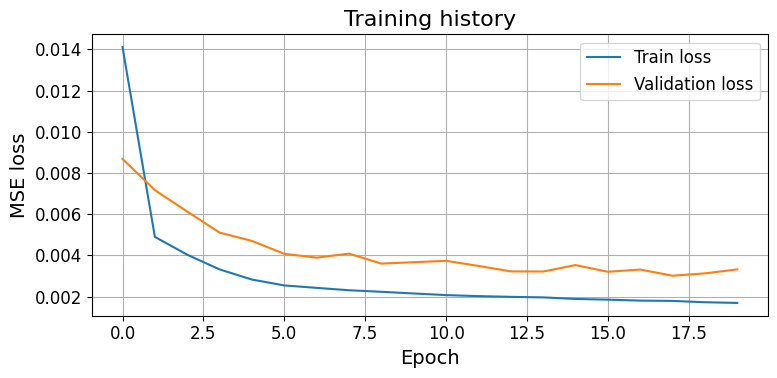

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Validation forecast

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Validation prediction shape: (2060, 24)
Number of validation sequences: 2060
Number of timestamps: 2060
Selected index: 1247
Forecast start time: 2025-02-25 04:00:00


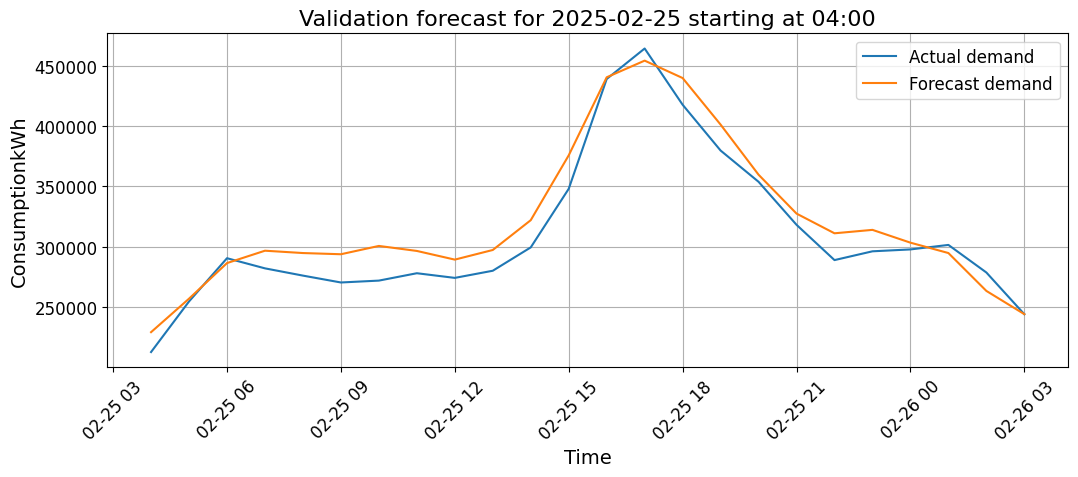

In [13]:
# %% Validation prediction

y_val_pred_scaled = model.predict(X_val_seq)

y_val_pred = y_scaler.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
).reshape(y_val_pred_scaled.shape)

y_val_true = y_scaler.inverse_transform(
    y_val_seq.reshape(-1, 1)
).reshape(y_val_seq.shape)

print("Validation prediction shape:", y_val_pred.shape)


# %% Create validation timestamps

val_times = trainval_df.index[-val_size:]

val_forecast_start_times = val_times[
    look_back : len(val_times) - look_ahead + 1
]

print("Number of validation sequences:", len(y_val_true))
print("Number of timestamps:", len(val_forecast_start_times))


# %% Select random 06:00 forecast

six_am_mask = val_forecast_start_times.hour == 4
six_am_indices = np.where(six_am_mask)[0]

if len(six_am_indices) == 0:
    raise ValueError("No validation forecasts start at 06:00")

np.random.seed(42)  # optional, remove for full randomness
example_idx = np.random.choice(six_am_indices)

start_time = val_forecast_start_times[example_idx]

print("Selected index:", example_idx)
print("Forecast start time:", start_time)


# %% Plot 24 hour forecast from 06:00

time_axis = pd.date_range(
    start=start_time,
    periods=look_ahead,
    freq="h"
)

plt.figure(figsize=(11, 5))

plt.plot(time_axis, y_val_true[example_idx], label="Actual demand")
plt.plot(time_axis, y_val_pred[example_idx], label="Forecast demand")

plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("ConsumptionkWh")
forecast_date = start_time.date()
plt.title(f"Validation forecast for {forecast_date} starting at {start_time.strftime('%H:%M')}")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Final test evaluation 

24 hour horizon RMSE: 23955.844 kWh
24 hour horizon MAE: 17824.016 kWh
24 hour horizon R²: 0.796
Hour 01 RMSE: 15735.744 kWh
Hour 02 RMSE: 20685.260 kWh
Hour 03 RMSE: 23370.993 kWh
Hour 04 RMSE: 22729.788 kWh
Hour 05 RMSE: 22302.760 kWh
Hour 06 RMSE: 23509.329 kWh
Hour 07 RMSE: 22770.986 kWh
Hour 08 RMSE: 23593.639 kWh
Hour 09 RMSE: 24535.685 kWh
Hour 10 RMSE: 24124.849 kWh
Hour 11 RMSE: 24258.699 kWh
Hour 12 RMSE: 24082.573 kWh
Hour 13 RMSE: 25310.495 kWh
Hour 14 RMSE: 25260.668 kWh
Hour 15 RMSE: 25083.409 kWh
Hour 16 RMSE: 25332.485 kWh
Hour 17 RMSE: 24688.574 kWh
Hour 18 RMSE: 25739.490 kWh
Hour 19 RMSE: 25432.734 kWh
Hour 20 RMSE: 25591.202 kWh
Hour 21 RMSE: 25287.497 kWh
Hour 22 RMSE: 24502.358 kWh
Hour 23 RMSE: 24560.994 kWh
Hour 24 RMSE: 24302.598 kWh
Average 24 hour forecast RMSE: 22249.353 kWh
Minimum 24 hour forecast RMSE: 8052.988 kWh
Maximum 24 hour forecast RMSE: 59922.443 kWh
Number of test sequences: 697
Number of forecast start timestamps: 697


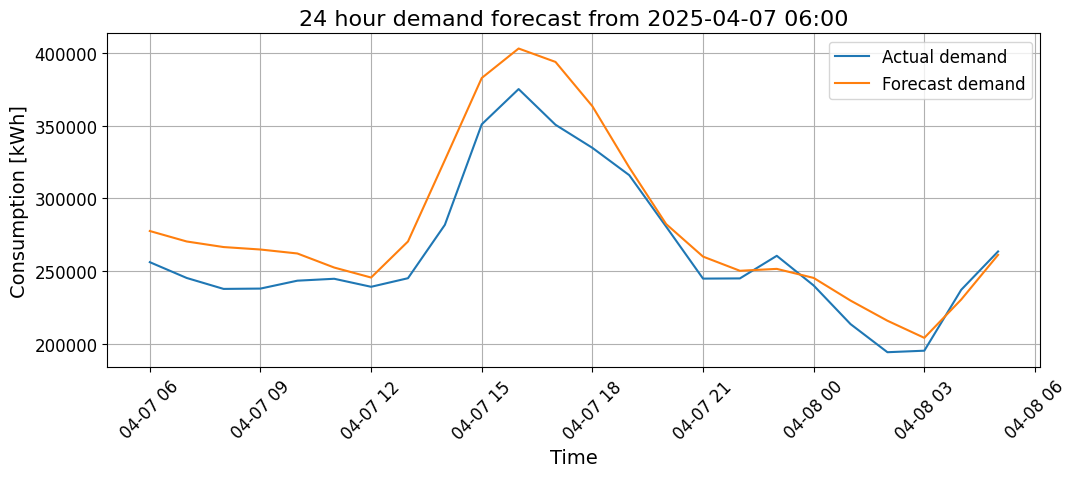

2025-04-01 00:00:00
2025-04-30 00:00:00


In [19]:
# %% Final test evaluation and plot

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict on test set
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# Inverse transform full 24 hour horizon
y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

# Overall 24 hour horizon metrics
overall_rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
overall_mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
overall_r2 = r2_score(y_true.flatten(), y_pred.flatten())

print(f"24 hour horizon RMSE: {overall_rmse:.3f} kWh")
print(f"24 hour horizon MAE: {overall_mae:.3f} kWh")
print(f"24 hour horizon R²: {overall_r2:.3f}")

# RMSE for each forecast hour
hourly_rmse = []

for h in range(y_true.shape[1]):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    hourly_rmse.append(rmse_h)
    print(f"Hour {h+1:02d} RMSE: {rmse_h:.3f} kWh")

# RMSE for each 24 hour forecast sequence
daily_rmse = np.array([
    np.sqrt(mean_squared_error(y_true[i], y_pred[i]))
    for i in range(len(y_true))
])

print(f"Average 24 hour forecast RMSE: {daily_rmse.mean():.3f} kWh")
print(f"Minimum 24 hour forecast RMSE: {daily_rmse.min():.3f} kWh")
print(f"Maximum 24 hour forecast RMSE: {daily_rmse.max():.3f} kWh")

# Forecast start timestamps based directly on sequence count
test_forecast_start_times = test_input_index[
    look_back : look_back + len(y_true)
]

# Sanity check
print("Number of test sequences:", len(y_true))
print("Number of forecast start timestamps:", len(test_forecast_start_times))

# Pick one random test forecast that starts at 06:00
six_am_mask = test_forecast_start_times.hour == 6
six_am_indices = np.where(six_am_mask)[0]

if len(six_am_indices) == 0:
    raise ValueError("No test forecasts start at 06:00")

np.random.seed(42)
example_idx = np.random.choice(six_am_indices)

start_time = test_forecast_start_times[example_idx]
time_axis = pd.date_range(start=start_time, periods=look_ahead, freq="h")

# Plot one 24 hour forecast
plt.figure(figsize=(11, 5))
plt.plot(time_axis, y_true[example_idx], label="Actual demand")
plt.plot(time_axis, y_pred[example_idx], label="Forecast demand")

plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("Consumption [kWh]")
plt.title(
    f"24 hour demand forecast from {start_time.strftime('%Y-%m-%d %H:%M')}"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(test_forecast_start_times.min())
print(test_forecast_start_times.max())

In [15]:
print("test_df length:", len(test_df))
print("look_back:", look_back)
print("look_ahead:", look_ahead)

expected_sequences = len(test_df) - look_back - look_ahead + 1
print("Expected sequences from test_df:", expected_sequences)

print("Actual X_test_seq:", len(X_test_seq))
print("Actual y_test_seq:", len(y_test_seq))

test_df length: 720
look_back: 72
look_ahead: 24
Expected sequences from test_df: 625
Actual X_test_seq: 697
Actual y_test_seq: 697


### The average daily profile represents the predicted consumption pattern for a typical day in April.

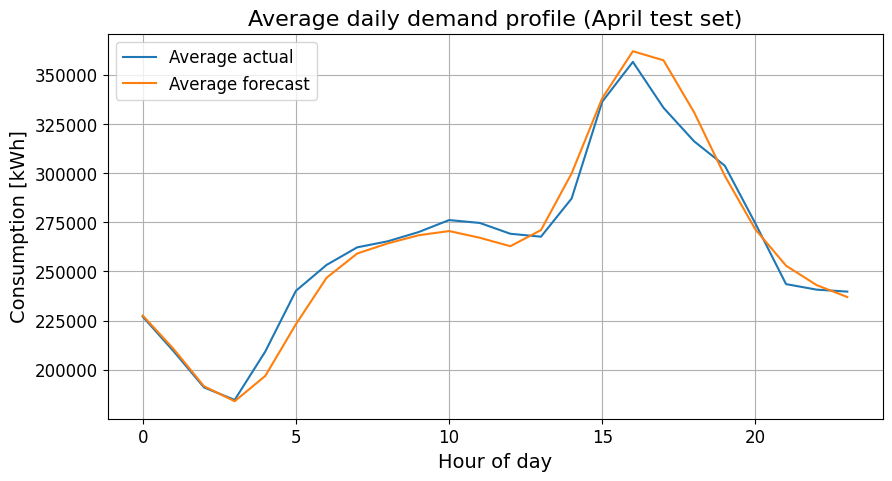

In [21]:
pred_series = []
true_series = []

for i in range(len(y_pred)):
    time_index = pd.date_range(
        start=test_forecast_start_times[i],
        periods=24,
        freq="h"
    )
    
    pred_series.append(pd.Series(y_pred[i], index=time_index))
    true_series.append(pd.Series(y_true[i], index=time_index))

pred_series = pd.concat(pred_series)
true_series = pd.concat(true_series)

# Group by hour of day (THIS is the key step)
avg_pred_hour = pred_series.groupby(pred_series.index.hour).mean()
avg_true_hour = true_series.groupby(true_series.index.hour).mean()

plt.figure(figsize=(10,5))
plt.plot(avg_true_hour.index, avg_true_hour, label="Average actual")
plt.plot(avg_pred_hour.index, avg_pred_hour, label="Average forecast")

plt.xlabel("Hour of day")
plt.ylabel("Consumption [kWh]")
plt.title("Average daily demand profile (April test set)")
plt.legend()
plt.grid()
plt.show()

### Saving output for App 

In [16]:
import os
import pickle

save_dir = os.getcwd()

model_path = os.path.join(save_dir, "lstm_model.keras")
scaler_x_path = os.path.join(save_dir, "scaler_X.pkl")
scaler_y_path = os.path.join(save_dir, "scaler_y.pkl")
feature_cols_path = os.path.join(save_dir, "feature_cols.pkl")

with open(feature_cols_path, "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved feature columns to:", feature_cols_path)

model.save(model_path)

with open(scaler_x_path, "wb") as f:
    pickle.dump(X_scaler, f)

with open(scaler_y_path, "wb") as f:
    pickle.dump(y_scaler, f)

print("Saved model to:", model_path)
print("Saved X scaler to:", scaler_x_path)
print("Saved y scaler to:", scaler_y_path)

Saved feature columns to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\feature_cols.pkl
Saved model to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\lstm_model.keras
Saved X scaler to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\scaler_X.pkl
Saved y scaler to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\scaler_y.pkl


In [17]:
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(f"MAPE: {mape:.2f} %")

MAPE: 6.73 %


In [18]:
# Mean demand level (true values)
mean_demand = np.mean(y_true)

# RMSE as percentage
rmse_percent = (overall_rmse / mean_demand) * 100

print(f"Mean demand: {mean_demand:.3f} kWh")
print(f"RMSE as percentage: {rmse_percent:.2f} %")

Mean demand: 263808.721 kWh
RMSE as percentage: 9.08 %
